# Task 2: Predict Future Stock Prices (Short-Term)

**Objective:** Use historical stock data to predict the next day's closing price.

**Dataset:** Historical stock data fetched via `yfinance` (Apple – AAPL)

**Model:** Random Forest

## 1. Install Dependencies

In [ ]:
!pip install yfinance scikit-learn pandas matplotlib -q
print('Dependencies installed.')

Dependencies installed.


## 2. Import Libraries

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('Libraries loaded.')

Libraries loaded.


## 3. Fetch Historical Stock Data

We use Apple (AAPL) as our stock. You can change the `TICKER` variable to any valid Yahoo Finance symbol (e.g. `TSLA`, `GOOGL`, `MSFT`).

In [ ]:
TICKER     = 'AAPL'
START_DATE = '2020-01-01'
END_DATE   = '2024-01-01'

# Download data from Yahoo Finance
df = yf.download(TICKER, start=START_DATE, end=END_DATE, progress=False)

# Flatten MultiIndex columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
df.dropna(inplace=True)

print(f'Ticker  : {TICKER}')
print(f'Shape   : {df.shape}')
print(f'Period  : {df.index[0].date()} → {df.index[-1].date()}')
df.head()

Ticker  : AAPL
Shape   : (1006, 5)
Period  : 2020-01-02 → 2023-12-29


/tmp/ipykernel_16280/3839539795.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, start=START_DATE, end=END_DATE, progress=False)


Price,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02,71.409785,72.460784,71.156682,72.400520,135480400
2020-01-03,71.629153,72.455966,71.472469,71.696648,146322800
2020-01-06,70.819208,72.306506,70.568510,72.267937,118387200
2020-01-07,72.277571,72.533087,71.708687,71.928047,108872000
2020-01-08,71.631567,73.386438,71.631567,73.085121,132079200


## 4. Exploratory Data Analysis

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1006 entries, 2020-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1006 non-null   float64
 1   High    1006 non-null   float64
 2   Low     1006 non-null   float64
 3   Close   1006 non-null   float64
 4   Volume  1006 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 47.2 KB
None


In [ ]:
print('Descriptive Statistics:')
df.describe().round(2)

Descriptive Statistics:


Price,Open,High,Low,Close,Volume
count,1006.00,1006.00,1006.00,1006.00,1.006000e+03
mean,137.83,139.44,136.33,137.96,9.895373e+07
std,33.35,33.48,33.22,33.36,5.439610e+07
min,55.11,55.21,51.37,54.21,2.404830e+07
25%,120.50,121.64,118.86,120.40,6.407675e+07
50%,142.67,144.39,141.15,142.82,8.467540e+07
75%,163.46,165.47,161.94,163.20,1.155069e+08
max,195.98,197.57,194.97,196.07,4.265100e+08


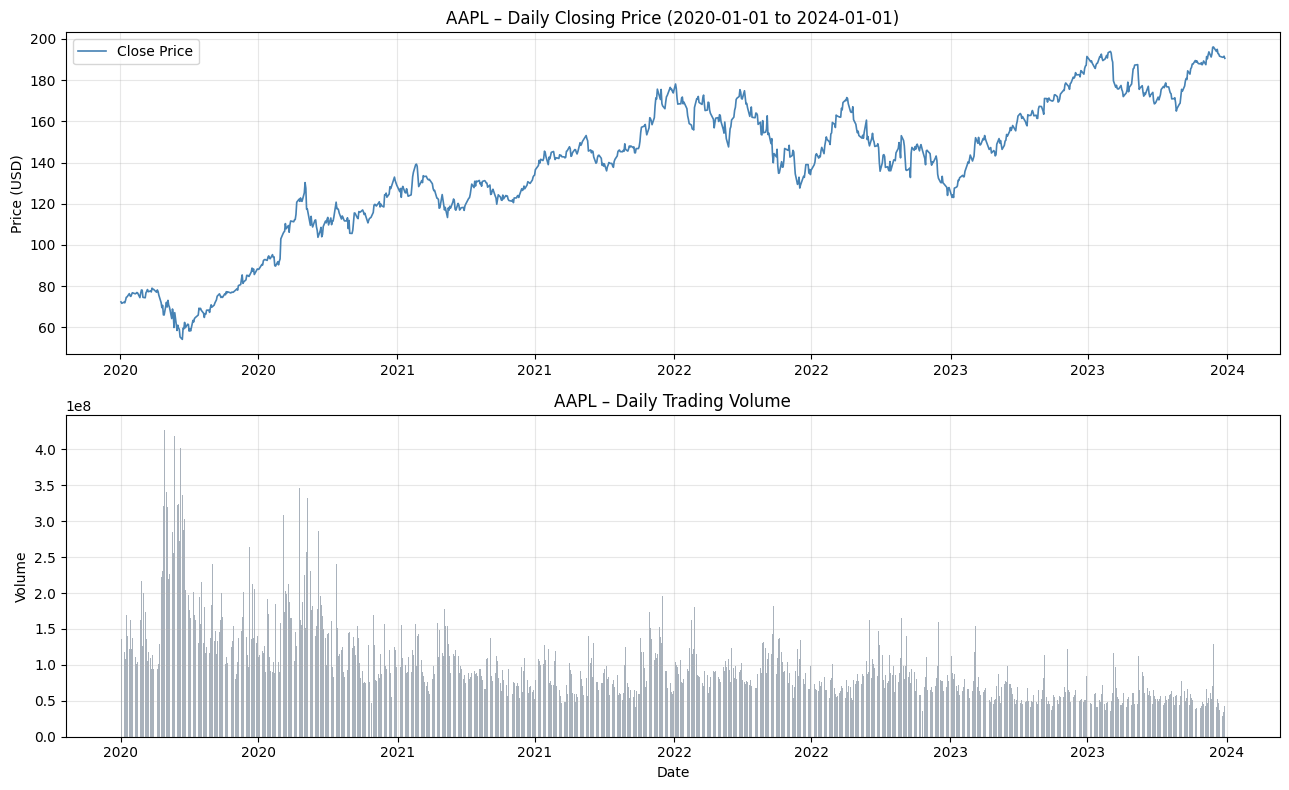

In [ ]:
# Closing price over time
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

axes[0].plot(df.index, df['Close'], color='steelblue', linewidth=1.2, label='Close Price')
axes[0].set_title(f'{TICKER} – Daily Closing Price ({START_DATE} to {END_DATE})')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[1].bar(df.index, df['Volume'], color='slategray', alpha=0.6, width=1)
axes[1].set_title(f'{TICKER} – Daily Trading Volume')
axes[1].set_ylabel('Volume')
axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('stock_eda.png', dpi=150)
plt.show()

## 5. Feature Engineering

We predict the **next day's closing price** (`Target`) using the current day's `Open`, `High`, `Low`, `Close`, and `Volume`, plus a set of derived features:

- **Daily return** – percentage change from previous close
- **Price range** – High minus Low for the day
- **5-day & 20-day moving averages** – short and medium-term trend signals
- **5-day rolling volatility** – standard deviation of recent returns

In [ ]:
df['Daily_Return']   = df['Close'].pct_change()                          # % change from prior day
df['Price_Range']    = df['High'] - df['Low']                            # intraday range
df['MA5']            = df['Close'].rolling(window=5).mean()              # 5-day moving average
df['MA20']           = df['Close'].rolling(window=20).mean()             # 20-day moving average
df['Volatility_5']   = df['Daily_Return'].rolling(window=5).std()        # 5-day rolling volatility

# Target: next day's closing price (shift by -1)
df['Target'] = df['Close'].shift(-1)

# Drop rows with NaN values introduced by rolling windows or the shift
df.dropna(inplace=True)

print(f'Dataset after feature engineering: {df.shape}')
df[['Close', 'MA5', 'MA20', 'Daily_Return', 'Volatility_5', 'Target']].head()

Dataset after feature engineering: (986, 11)


Price,Close,MA5,MA20,Daily_Return,Volatility_5,Target
Date,,,,,,
2020-01-30,78.070099,76.807460,75.217592,-0.001449,0.022724,74.608566
2020-01-31,74.608566,76.383205,75.327995,-0.044339,0.031370,74.403694
2020-02-03,74.403694,76.369228,75.463347,-0.002746,0.028346,76.860001
2020-02-04,76.860001,76.425150,75.692950,0.033013,0.029571,77.486755
2020-02-05,77.486755,76.285823,75.970885,0.008154,0.027933,78.393097


## 6. Prepare Features and Target

In [ ]:
FEATURES = ['Open', 'High', 'Low', 'Close', 'Volume',
            'Daily_Return', 'Price_Range', 'MA5', 'MA20', 'Volatility_5']

X = df[FEATURES].values
y = df['Target'].values
dates = df.index

# Chronological split – no shuffling for time series data
SPLIT_RATIO = 0.8
split_idx   = int(len(X) * SPLIT_RATIO)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
dates_test      = dates[split_idx:]

print(f'Training samples : {len(X_train)}')
print(f'Testing samples  : {len(X_test)}')

Training samples : 788
Testing samples  : 198


## 7. Train Models



### 7.1 Random Forest

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print('Random Forest trained.')

Random Forest trained.


In [ ]:
def evaluate_model(name, y_true, y_pred, current_close_prices):
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    r2    = r2_score(y_true, y_pred)
    mape  = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    # Calculate directional accuracy
    actual_direction    = np.sign(y_true - current_close_prices)
    predicted_direction = np.sign(y_pred - current_close_prices)
    directional_accuracy = np.mean(actual_direction == predicted_direction) * 100

    print(f'--- {name} ---')
    print(f'  MAE   : ${mae:.2f}')
    print(f'  RMSE  : ${rmse:.2f}')
    print(f'  R²    : {r2:.4f}')
    print(f'  MAPE  : {mape:.2f}%')

# Get current close prices for the test set from the FEATURES array
current_close_test = X_test[:, FEATURES.index('Close')]

rf_metrics = evaluate_model('Random Forest', y_test, rf_preds, current_close_test)

--- Random Forest ---
  MAE   : $7.17
  RMSE  : $9.76
  R²    : 0.1327
  MAPE  : 3.86%


## 8. Visualise Actual vs Predicted Prices

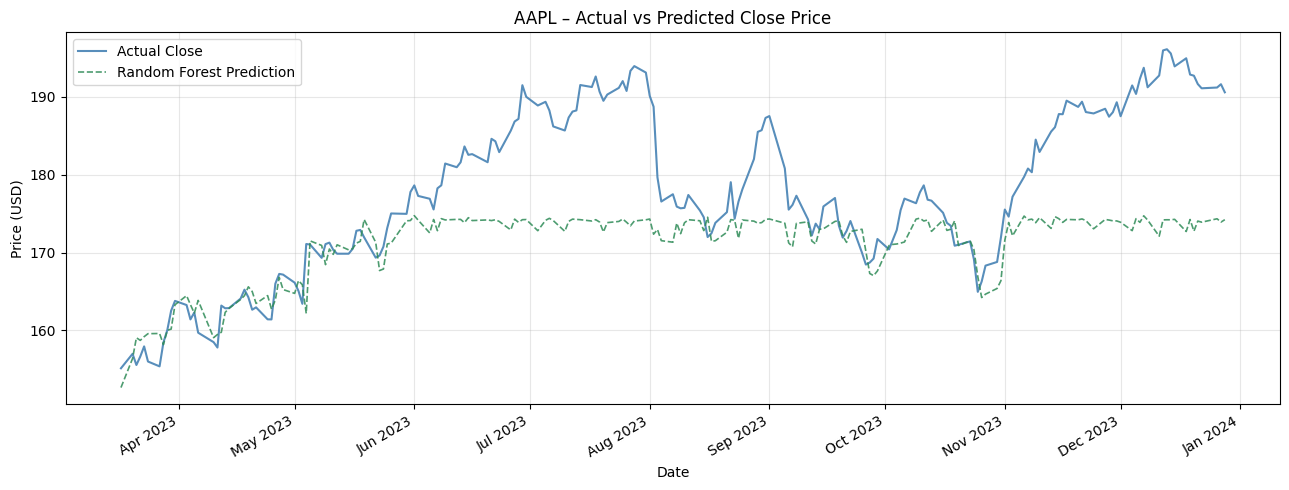

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(13, 5))

# Only plot for Random Forest
preds = rf_preds
name = 'Random Forest'
colour = 'seagreen'

ax.plot(dates_test, y_test,  color='steelblue', linewidth=1.5,
        label='Actual Close', alpha=0.9)
ax.plot(dates_test, preds,   color=colour,      linewidth=1.2,
        label=f'{name} Prediction', linestyle='--', alpha=0.85)
ax.set_title(f'{TICKER} – Actual vs Predicted Close Price')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

ax.set_xlabel('Date') # Now directly on the single ax
plt.tight_layout()
plt.savefig('stock_predictions.png', dpi=150)
plt.show()

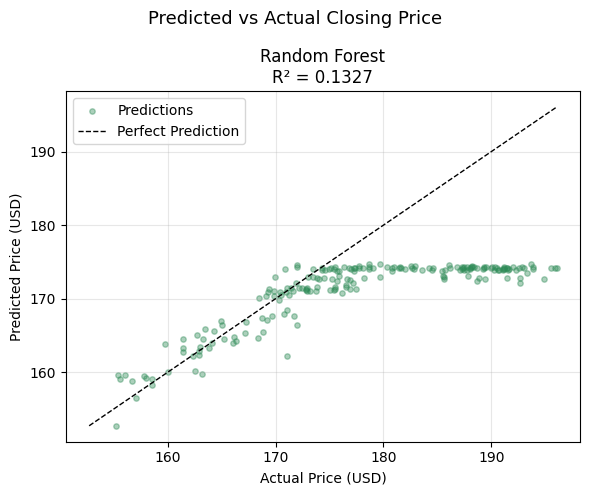

In [ ]:
# Scatter plot – predicted vs actual (closer to diagonal = better)
fig, ax = plt.subplots(1, 1, figsize=(6, 5)) # Changed to 1, 1 for a single plot

# Only plot for Random Forest
preds = rf_preds
name = 'Random Forest'
colour = 'seagreen'

ax.scatter(y_test, preds, color=colour, alpha=0.4, s=15, label='Predictions')
min_val = min(y_test.min(), preds.min())
max_val = max(y_test.max(), preds.max())
ax.plot([min_val, max_val], [min_val, max_val],
        'k--', linewidth=1, label='Perfect Prediction')
ax.set_title(f'{name}\nR² = {r2_score(y_test, preds):.4f}')
ax.set_xlabel('Actual Price (USD)')
ax.set_ylabel('Predicted Price (USD)')
ax.legend()

plt.suptitle('Predicted vs Actual Closing Price', fontsize=13) # This will be the main title
plt.tight_layout()
plt.savefig('stock_scatter.png', dpi=150)
plt.show()

## 9. Feature Importance (Random Forest)

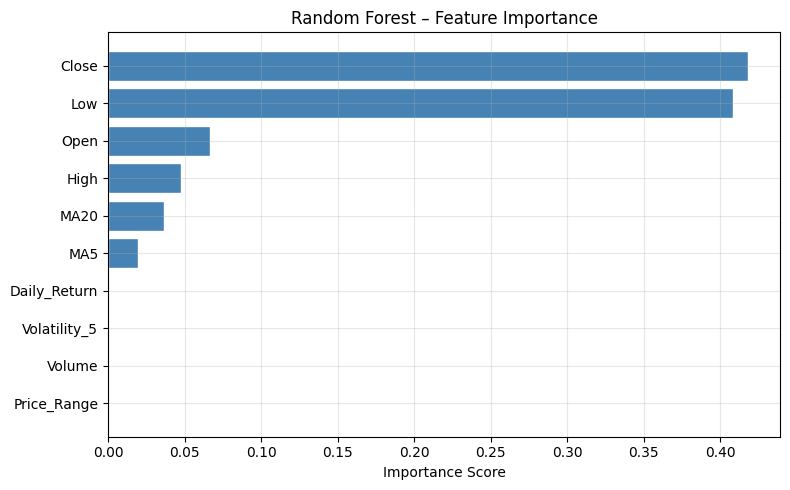

Top 3 most important features:
Feature  Importance
  Close    0.418010
    Low    0.408372
   Open    0.066516


In [ ]:
importances = rf_model.feature_importances_
feature_df  = pd.DataFrame({'Feature': FEATURES, 'Importance': importances})
feature_df  = feature_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feature_df['Feature'], feature_df['Importance'],
         color='steelblue', edgecolor='white')
plt.title('Random Forest – Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('stock_feature_importance.png', dpi=150)
plt.show()

print('Top 3 most important features:')
print(feature_df.sort_values('Importance', ascending=False).head(3).to_string(index=False))